# GAME Category Deep Dive

This notebook focuses on the GAME category and evaluates whether it is a good startup target or a high-risk market. It also checks price strategy and install distribution to understand why GAME is dominant in total scale but not necessarily the safest business choice.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("../data/googleplaystore_cleaned.csv")
game_df = df[df["Category"] == "GAME"].copy()

game_df["Price"] = game_df["Price"].astype(str).str.replace("$", "", regex=False)
game_df["Price"] = pd.to_numeric(game_df["Price"], errors="coerce").fillna(0)

game_df["Primary_Genre"] = game_df["Genres"].str.split(";").str[0]
print(game_df.head())

                   App Category  Rating   Reviews Size    Installs  Type  \
1275            ROBLOX     GAME     4.5   4447388  67M   100000000  Free   
1276    Subway Surfers     GAME     4.5  27722264  76M  1000000000  Free   
1277  Candy Crush Saga     GAME     4.4  22426677  74M   500000000  Free   
1278         Solitaire     GAME     4.7    254258  23M    10000000  Free   
1279    Bubble Shooter     GAME     4.5    148897  46M    10000000  Free   

      Price Content Rating                        Genres Last Updated  \
1275    0.0   Everyone 10+  Adventure;Action & Adventure    31-Jul-18   
1276    0.0   Everyone 10+                        Arcade    12-Jul-18   
1277    0.0       Everyone                        Casual     5-Jul-18   
1278    0.0       Everyone                          Card     1-Aug-18   
1279    0.0       Everyone                        Casual    17-Jul-18   

       Current Ver   Android Ver Primary_Genre  
1275  2.347.225742    4.1 and up     Adventure  
1276  

In [2]:
# Compare installation performance of free vs paid games
free_paid_summary = (
    game_df.assign(is_free=(game_df["Price"] == 0))
    .groupby("is_free")["Installs"]
    .agg(["count", "mean", "median"])
)
free_paid_summary

,count,mean,median
is_free,,,
False,76,2.763061e+05,10000.0
True,836,1.657627e+07,1000000.0


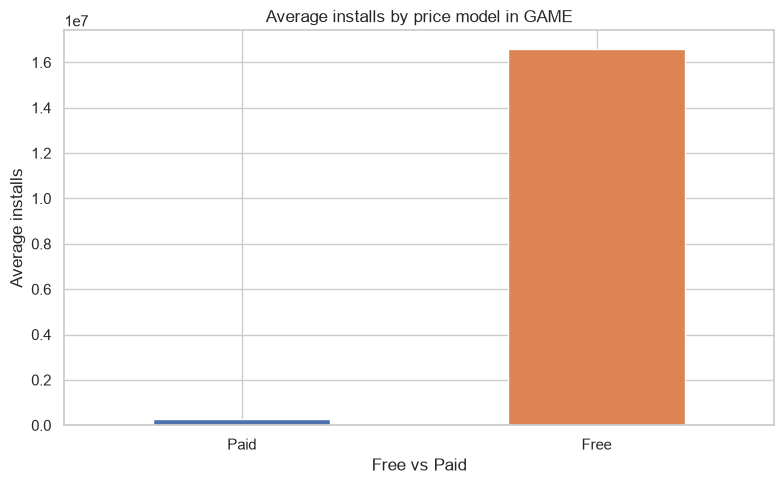

In [3]:
# Free vs paid comparison chart
ax = (
    game_df.assign(is_free=(game_df["Price"] == 0))
    .groupby("is_free")["Installs"]
    .mean()
    .plot(kind="bar", figsize=(8, 5), color=["#4c72b0", "#dd8452"])
)
ax.set_title("Average installs by price model in GAME")
ax.set_xlabel("Free vs Paid")
ax.set_ylabel("Average installs")
ax.set_xticklabels(["Paid", "Free"], rotation=0)
plt.tight_layout()
plt.show()

This chart shows that free games receive far more installs than paid games. For a startup, this means GAME is highly dependent on free acquisition, retention, and user growth loops rather than premium pricing. A paid-only strategy is much harder to scale in this category.

In [4]:
# Genre-level analysis in GAME
genre_summary = (
    game_df.groupby("Primary_Genre")["Installs"]
    .agg(["count", "mean", "median"])
    .sort_values("median", ascending=False)
    .head(10)
)
genre_summary

,count,mean,median
Primary_Genre,,,
Sports,6,5.266667e+07,55000000.0
Casual,27,8.551852e+07,10000000.0
Puzzle,24,2.513333e+07,10000000.0
Strategy,17,2.690000e+07,10000000.0
Simulation,12,1.343333e+07,10000000.0
Role Playing,15,7.273333e+06,5000000.0
Word,22,7.689659e+06,3000000.0
Action,295,1.189165e+07,1000000.0
Racing,86,1.628193e+07,1000000.0


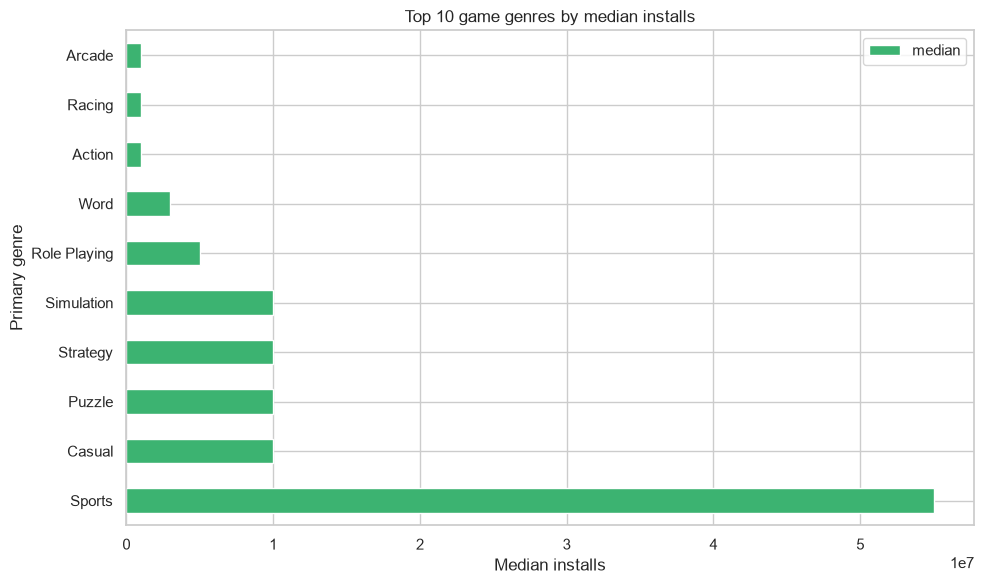

In [5]:
# Top 10 game genres by median installs
ax = genre_summary[["median"]].plot(kind="barh", figsize=(10, 6), color="mediumseagreen")
ax.set_title("Top 10 game genres by median installs")
ax.set_xlabel("Median installs")
ax.set_ylabel("Primary genre")
plt.tight_layout()
plt.show()

The median install view is useful because it filters out the biggest outliers. Genres with high median installs still point to strong demand, but they often also come with higher competition and more expensive user acquisition. This is why a strong niche or distinct product angle matters more than simply entering the largest game subgenre.

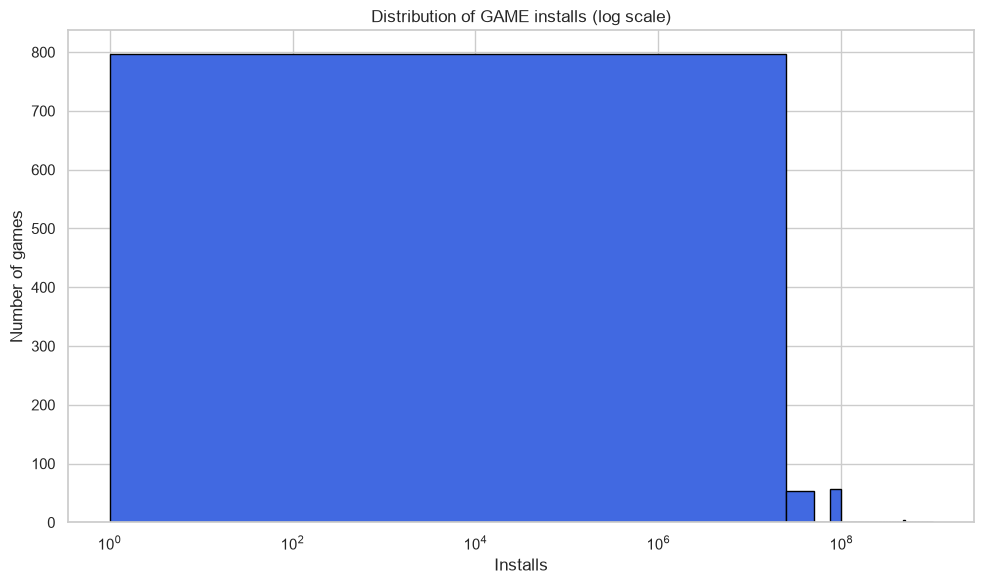

In [6]:
# Distribution of GAME installs using a log scale to reveal skewness
plt.figure(figsize=(10, 6))
plt.hist(game_df["Installs"], bins=40, edgecolor="black", color="royalblue")
plt.xscale("log")
plt.title("Distribution of GAME installs (log scale)")
plt.xlabel("Installs")
plt.ylabel("Number of games")
plt.tight_layout()
plt.show()

This histogram shows that GAME installs are extremely skewed: a small number of games capture massive reach while many others have much smaller distribution. That pattern supports the idea that GAME is a winner-takes-most market, which makes it strong for scale but risky for startup entry.

## Final GAME conclusion

GAME is the largest category by total installs, but its install distribution is highly skewed and dominated by a few successful products. The category offers huge scale and a strong user base, yet it is also a high-risk environment for a startup because free distribution, high competition, and winner-takes-most behavior all increase the cost of entry.

The final recommendation is therefore:

- If the goal is maximum reach, GAME is the largest market and should be considered.
- If the goal is safer startup execution, EDUCATION or a smaller utility category is more realistic.
- If the goal is passive income, EDUCATION and subscription-friendly niches are more durable than a large-scale casual game launch.